## Exploring Data

In [5]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)    #tells number of rows and cols
print(train.head())   #outputs csv data
print(train.info())     #tells datatype of each column
print(train.describe())     #tells count,minmax,std,quartiles
print(train.isnull().sum())     #count null values
print(train['Irrigation_Need'].value_counts())  #counts the target

(630000, 21)
   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy     4.92          32.58            1.01   
1   1      Clay     7.08          56.61            0.44   
2   2      Clay     5.69          27.71            0.81   
3   3     Sandy     5.65          13.32            1.33   
4   4      Clay     7.96          59.14            0.38   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                     3.05          15.01     50.61       725.99   
1                     2.00          22.92     67.86       985.66   
2                     2.83          26.97     92.22      2201.70   
3                     0.87          13.32     61.57      1357.33   
4                     0.96          20.22     91.11      1538.20   

   Sunlight_Hours  ...  Crop_Type Crop_Growth_Stage  Season Irrigation_Type  \
0            5.90  ...  Sugarcane            Sowing    Zaid            Drip   
1            6.98  ...      Wheat        Vegetative  Kharif      

## Preprocessing

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

TARGET = 'Irrigation_Need'
X = train.drop(columns=['id',TARGET])
y = train[TARGET]
X_test = test.drop(columns=['id'])

#Encode Categorial Columns - if any
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    
#Encode Target
le_target = LabelEncoder()
y = le_target.fit_transform(y)

#Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

C:\Users\ssa56\AppData\Local\Temp\ipykernel_18272\676511129.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:


## Model Training

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree":    DecisionTreeClassifier(random_state=42),
    "Naive Bayes":      GaussianNB(),
    "Logistic Reg":     LogisticRegression(max_iter=1000, random_state=42),
    "KNN":              KNeighborsClassifier(),
    "Random Forest":    RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='accuracy', n_jobs=-1)
    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

Decision Tree: 0.9702 ± 0.0005
Naive Bayes: 0.8271 ± 0.0010
Logistic Reg: 0.7488 ± 0.0008
KNN: 0.8358 ± 0.0013
Random Forest: 0.9852 ± 0.0002


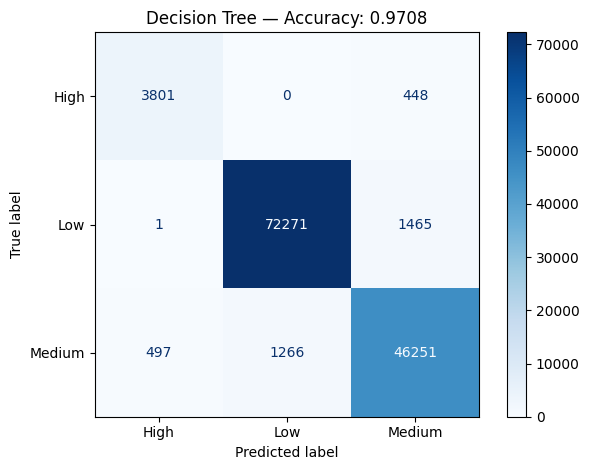

Decision Tree: 0.9708


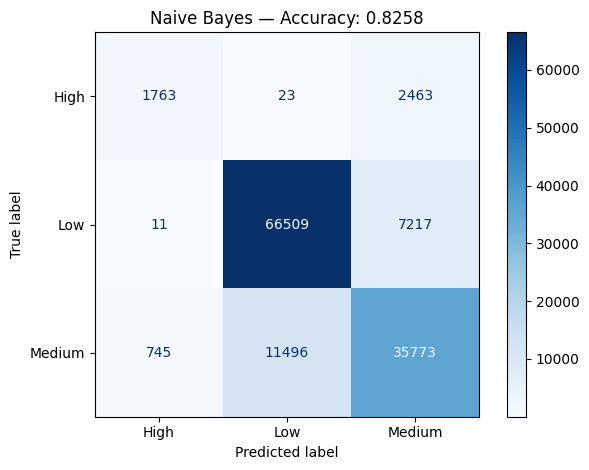

Naive Bayes: 0.8258


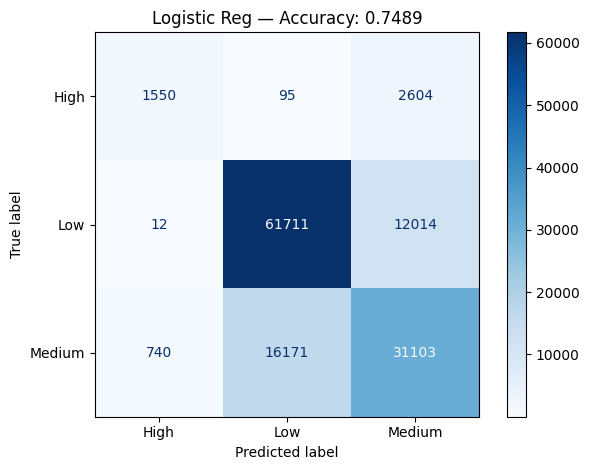

Logistic Reg: 0.7489


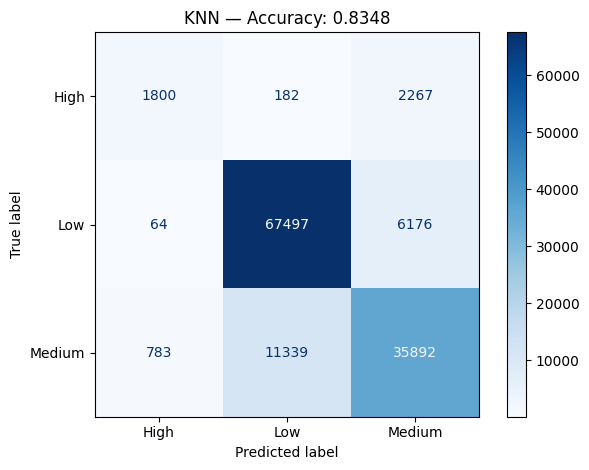

KNN: 0.8348


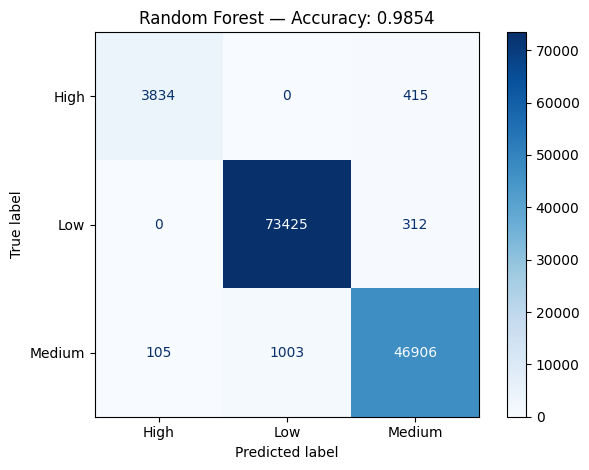

Random Forest: 0.9854


In [8]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_tr, X_val, y_tr, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

for name, model in models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    cm = confusion_matrix(y_val, preds)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"{name} — Accuracy: {acc:.4f}")
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ', '_')}.png")
    plt.show()
    print(f"{name}: {acc:.4f}")

## Best Model

In [9]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_scaled, y)  # full train data

# Generate predictions
test_preds = best_model.predict(X_test_scaled)
test_preds_labels = le_target.inverse_transform(test_preds)

# Submission file
submission = pd.DataFrame({
    'id': test['id'],
    TARGET: test_preds_labels
})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print("Done")

       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
Done


In [14]:
print("Training Samples: ", train.shape[0])
print("Test Samples: ", test.shape[0])
print("Number of Features: ", train.shape[1]-2)
print("Target Class: ", train['Irrigation_Need'].unique())
print("Class Distribution: ", train['Irrigation_Need'].value_counts())
print("Missing Values: ", train.isnull().sum().any())

Training Samples:  630000
Test Samples:  270000
Number of Features:  19
Target Class:  <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Class Distribution:  Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64
Missing Values:  False
